<a href="https://colab.research.google.com/github/shabrii-naa/CV-JD-match-classifier/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [ ]:
!pip -q install gdown
import os, json, pickle, warnings, zipfile, ast, re, datetime, shutil
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
PLOT_COLOR = "#5C4DB1"

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, hamming_loss, multilabel_confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from google.colab import drive

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU        : {gpus if gpus else 'None — using CPU'}")
print("Libraries imported.")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries imported.


## 2. Configuration & Constants

In [ ]:
DRIVE_URL = "https://drive.google.com/file/d/1APLVYCnKNQb9jBDv33uYNvQ6YEgnmVWV/view?usp=sharing"

ZIP_PATH   = "/content/Capstone_Project.zip"
EXTRACT_TO = "/content/capstone"

if not os.path.exists(ZIP_PATH):
    print("Downloading dataset ZIP...")
    gdown.download(url=DRIVE_URL, output=ZIP_PATH, quiet=False, fuzzy=True)
else:
    print("ZIP already downloaded.")

if os.path.exists(EXTRACT_TO):
    shutil.rmtree(EXTRACT_TO)

os.makedirs(EXTRACT_TO, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_TO)

print("Done extracting dataset.")
print("Extracted to:", EXTRACT_TO)
print("Top-level files/folders:", os.listdir(EXTRACT_TO))

ZIP already downloaded.
Done extracting dataset.
Extracted to: /content/capstone
Top-level files/folders: ['Capstone-CV-Project']


In [ ]:
BASE_DIR = Path(EXTRACT_TO) / "Capstone-CV-Project"

PATHS = {
    "pair_labeled"  : BASE_DIR / "Labeled"          / "pair_labeled (1).csv",
    "cv_processed"  : BASE_DIR / "Processed"        / "cv_processed.csv",
    "job_processed" : BASE_DIR / "Processed"        / "job_processed.csv",
    "skill_taxonomy": BASE_DIR / "Skill_Dictionary" / "skill_taxonomy_clean.json",
    "skill_dict"    : BASE_DIR / "Skill_Dictionary" / "skill_dictionary.csv",
    "model_keras"   : Path("/content") / "skill_gap_model.keras",
    "tfidf_pkl"     : Path("/content") / "tfidf_vectorizer.pkl",
    "label_json"    : Path("/content") / "skill_labels.json",
    "log_dir"      : Path("/content/logs/fit"),
}

CONFIG = {
    "tfidf_max_features"      : 15_000,
    "tfidf_ngram_range"       : (1, 2),
    "tfidf_sublinear_tf"      : True,
    "prob_threshold"          : 0.35,
    "hidden_units"            : [256, 128, 64],
    "dropout_rate"            : 0.3,
    "l2_lambda"               : 1e-4,
    "learning_rate"           : 3e-4,
    "batch_size"              : 32,
    "epochs"                  : 100,
    "early_stopping_patience" : 15,
    "test_size"               : 0.15,
    "val_size"                : 0.15,
    "random_state"            : 42,
}

print(" CONFIG:")
for k, v in CONFIG.items():
    print(f"   {k:<30} : {v}")

 CONFIG:
   tfidf_max_features             : 15000
   tfidf_ngram_range              : (1, 2)
   tfidf_sublinear_tf             : True
   prob_threshold                 : 0.35
   hidden_units                   : [256, 128, 64]
   dropout_rate                   : 0.3
   l2_lambda                      : 0.0001
   learning_rate                  : 0.0003
   batch_size                     : 32
   epochs                         : 100
   early_stopping_patience        : 15
   test_size                      : 0.15
   val_size                       : 0.15
   random_state                   : 42


In [ ]:
with open(PATHS["skill_taxonomy"], "r") as f:
    skill_taxonomy_raw = json.load(f)

SKILL_TAXONOMY = {
    item["skill_name"]: {"category": item["skill_category"], "type": item["skill_type"]}
    for item in skill_taxonomy_raw
}
SKILL_LABELS = sorted(SKILL_TAXONOMY.keys())
N_SKILLS     = len(SKILL_LABELS)

print(f"Total skills : {N_SKILLS}")
print(f"Skills       : {SKILL_LABELS}")

Total skills : 28
Skills       : ['agile', 'aws', 'communication', 'css', 'cyber security', 'devops', 'django', 'docker', 'ethical hacking', 'flask', 'git', 'html', 'jira', 'linux', 'marketing', 'mongodb', 'mysql', 'nodejs', 'penetration testing', 'photoshop', 'postgresql', 'python', 'react', 'scrum', 'seo', 'sql', 'ui', 'ux']


## 3. Data Loading & Initial Inspection

In [ ]:
df = pd.read_csv(PATHS["pair_labeled"])
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"Nulls   :\n{df.isnull().sum().to_string()}")
df.head(3)

Shape   : (600, 10)
Columns : ['cv_id', 'job_id', 'cv_text_clean', 'job_description_clean', 'candidate_skills', 'required_skills', 'matched_skills', 'missing_skills', 'match_score', 'label']
Nulls   :
cv_id                    0
job_id                   0
cv_text_clean            0
job_description_clean    0
candidate_skills         0
required_skills          0
matched_skills           0
missing_skills           0
match_score              0
label                    0


,cv_id,job_id,cv_text_clean,job_description_clean,candidate_skills,required_skills,matched_skills,missing_skills,match_score,label
0,24854026,3903847750,finance consultant summary strategic and anal...,description are you excited about defining the...,"['sql', 'marketing', 'testing', 'excel', 'data...","['sql', 'marketing', 'testing', 'excel', 'lead...","['excel', 'testing', 'sql', 'marketing']",['leadership'],0.80,1
1,17624934,3891014230,senior manager specialist leader healthcare e...,allegient defense is a small business providin...,"['leadership', 'communication']","['excel', 'leadership', 'communication']","['leadership', 'communication']",['excel'],0.67,1
2,51415089,3901693878,owner consultant summary proven marketing and...,employer industry personal development and wea...,['marketing'],"['communication', 'problem solving', 'marketing']",['marketing'],"['communication', 'problem solving']",0.33,0


In [ ]:
df_cv       = pd.read_csv(PATHS["cv_processed"], usecols=["ID", "Category", "candidate_skills"])
df_job      = pd.read_csv(PATHS["job_processed"], usecols=["job_id", "title", "formatted_experience_level", "required_skills"])
df_skill_dict = pd.read_csv(PATHS["skill_dict"])

print(f"cv_processed   : {df_cv.shape}")
print(f"job_processed  : {df_job.shape}")
print(f"skill_dict     : {df_skill_dict.shape}")
print(f"\nLabel dist:\n{df['label'].value_counts().to_string()}")
print(f"\nmatch_score stats:\n{df['match_score'].describe().round(3).to_string()}")

cv_processed   : (2484, 3)
job_processed  : (94440, 4)
skill_dict     : (59, 1)

Label dist:
label
1    421
0    179

match_score stats:
count    600.000
mean       0.675
std        0.324
min        0.000
25%        0.330
50%        0.670
75%        1.000
max        1.000


In [ ]:
# Parse skill columns
def parse_skill_col(series: pd.Series) -> pd.Series:
    def _parse(val):
        if isinstance(val, list): return val
        if pd.isna(val) or str(val).strip() in ("", "[]"): return []
        try: return ast.literal_eval(val)
        except: return [s.strip().lower() for s in str(val).split(",") if s.strip()]
    return series.apply(_parse)

df["candidate_skills_list"] = parse_skill_col(df["candidate_skills"])
df["required_skills_list"]  = parse_skill_col(df["required_skills"])
df["matched_skills_list"]   = parse_skill_col(df["matched_skills"])
df["missing_skills_list"]   = parse_skill_col(df["missing_skills"])

print("Sample required_skills_list:", df["required_skills_list"].iloc[0])
print("Skill columns parsed.")

Sample required_skills_list: ['sql', 'marketing', 'testing', 'excel', 'leadership']
Skill columns parsed.


## 4. Exploratory Data Analysis (EDA)

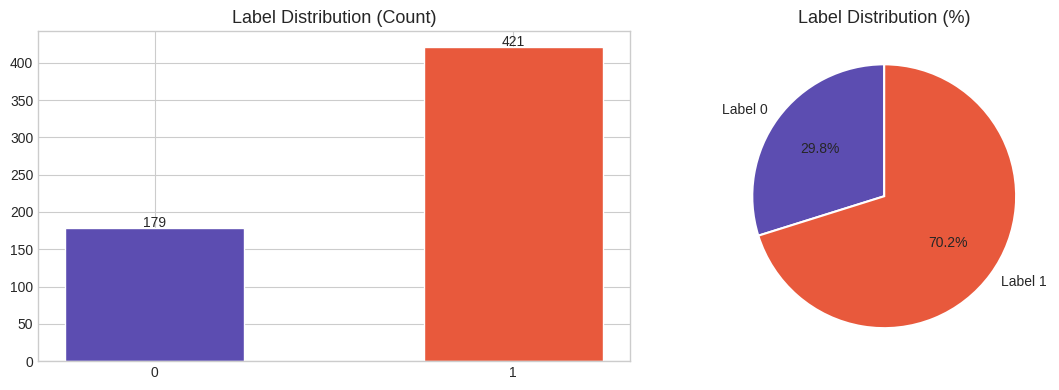

In [ ]:
# 4.1 Label Distribution
label_counts = df["label"].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(label_counts.index.astype(str), label_counts.values,
            color=[PLOT_COLOR, "#E8593C"], edgecolor="white", width=0.5)
axes[0].set_title("Label Distribution (Count)", fontsize=13)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v+1, str(v), ha="center")
axes[1].pie(label_counts.values, labels=[f"Label {l}" for l in label_counts.index],
            autopct="%1.1f%%", colors=[PLOT_COLOR, "#E8593C"], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Label Distribution (%)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/04_label_dist.png", dpi=150, bbox_inches="tight")
plt.show()

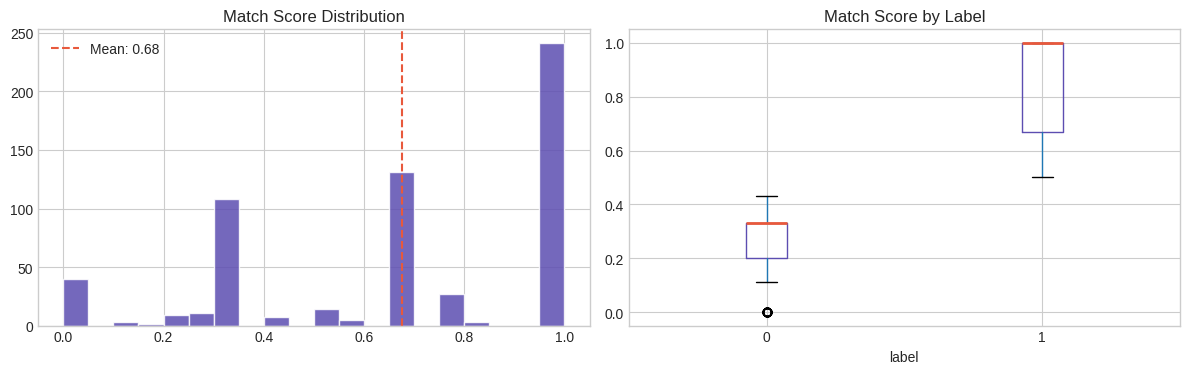

count    600.000
mean       0.675
std        0.324
min        0.000
25%        0.330
50%        0.670
75%        1.000
max        1.000


In [ ]:
# 4.2 Match Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["match_score"], bins=20, color=PLOT_COLOR, edgecolor="white", alpha=0.85)
axes[0].axvline(df["match_score"].mean(), color="#E8593C", linestyle="--",
                label=f"Mean: {df['match_score'].mean():.2f}")
axes[0].set_title("Match Score Distribution"); axes[0].legend()
df.boxplot(column="match_score", by="label", ax=axes[1],
           boxprops=dict(color=PLOT_COLOR), medianprops=dict(color="#E8593C", linewidth=2))
axes[1].set_title("Match Score by Label")
plt.suptitle("")
plt.tight_layout()
plt.savefig("/content/04_match_score.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["match_score"].describe().round(3).to_string())

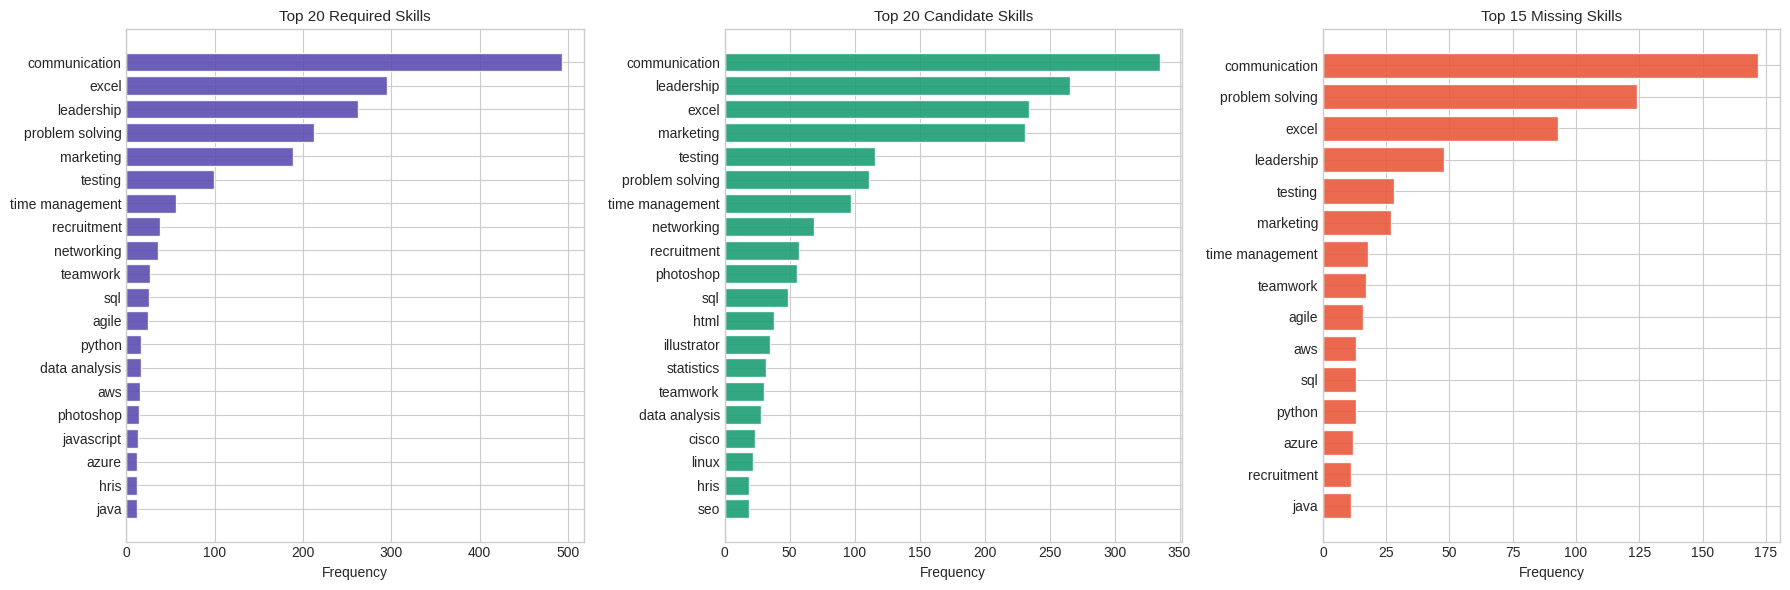

In [ ]:
# 4.3 Top Required & Candidate Skills
required_flat = [s for sub in df["required_skills_list"] for s in sub]
candidate_flat = [s for sub in df["candidate_skills_list"] for s in sub]
missing_flat   = [s for sub in df["missing_skills_list"]   for s in sub]

top_req  = pd.DataFrame(Counter(required_flat).most_common(20),  columns=["skill","count"])
top_cand = pd.DataFrame(Counter(candidate_flat).most_common(20), columns=["skill","count"])
top_miss = pd.DataFrame(Counter(missing_flat).most_common(15),   columns=["skill","count"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, data, title, color in zip(axes,
    [top_req, top_cand, top_miss],
    ["Top 20 Required Skills", "Top 20 Candidate Skills", "Top 15 Missing Skills"],
    [PLOT_COLOR, "#1D9E75", "#E8593C"]):
    ax.barh(data["skill"][::-1], data["count"][::-1], color=color, edgecolor="white", alpha=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig("/content/04_skills.png", dpi=150, bbox_inches="tight")
plt.show()

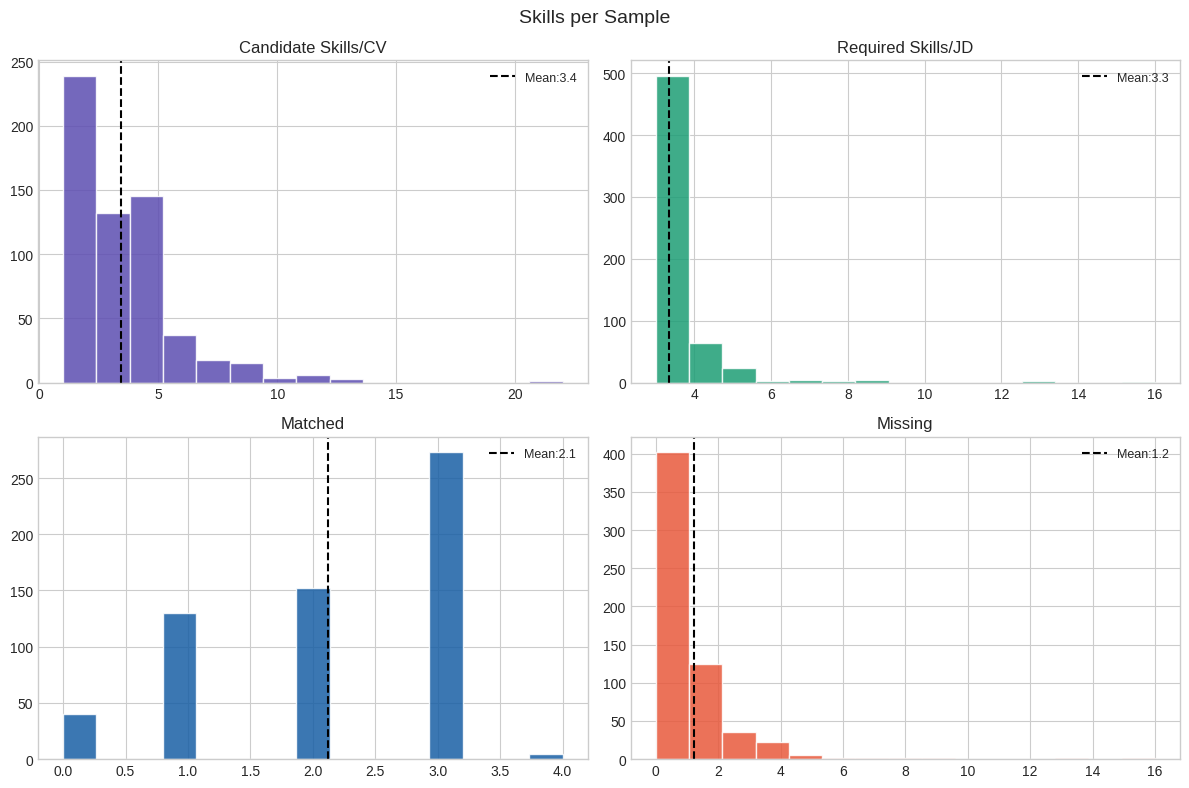

In [ ]:
# 4.4 Skills per Sample
df["n_candidate"] = df["candidate_skills_list"].apply(len)
df["n_required"]  = df["required_skills_list"].apply(len)
df["n_matched"]   = df["matched_skills_list"].apply(len)
df["n_missing"]   = df["missing_skills_list"].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, clr, title in zip(axes.flat,
    ["n_candidate","n_required","n_matched","n_missing"],
    [PLOT_COLOR,"#1D9E75","#185FA5","#E8593C"],
    ["Candidate Skills/CV","Required Skills/JD","Matched","Missing"]):
    ax.hist(df[col], bins=15, color=clr, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", linestyle="--", label=f"Mean:{df[col].mean():.1f}")
    ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle("Skills per Sample", fontsize=14)
plt.tight_layout()
plt.savefig("/content/04_skills_per_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Data Preprocessing & Cleaning

In [ ]:
# 5.1 Text Cleaning
def clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip(): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["jd_clean"] = df["job_description_clean"].fillna("").apply(clean_text)
df["cv_clean"] = df["cv_text_clean"].fillna("").apply(clean_text)

print(f"Empty jd_clean : {(df['jd_clean']=='').sum()}")
print(f"Empty cv_clean : {(df['cv_clean']=='').sum()}")
print(f"Sample jd_clean: {df['jd_clean'].iloc[0][:100]}")

Empty jd_clean : 0
Empty cv_clean : 0
Sample jd_clean: description are you excited about defining the partner marketing strategy at a fast growth subsidiar


In [ ]:
# 5.2 Gabungkan CV + JD sebagai input
df["combined_text"] = df["cv_clean"] + " " + df["jd_clean"]
print(f"Sample combined: {df['combined_text'].iloc[0][:120]}")
print(f"Combined len mean: {df['combined_text'].apply(len).mean():.0f} chars")

Sample combined: finance consultant summary strategic and analytical finance professional with years of success in reporting and analytic
Combined len mean: 9769 chars


In [ ]:
# 5.3 Feature & Label Arrays
X_text  = df["combined_text"].values
Y_label = df["label"].values

# 5.4 Class Weights
classes       = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=Y_label)
CLASS_WEIGHT_DICT = dict(zip(classes, class_weights))

print(f"Label 0 weight : {CLASS_WEIGHT_DICT[0]:.4f}")
print(f"Label 1 weight : {CLASS_WEIGHT_DICT[1]:.4f}")

Label 0 weight : 1.6760
Label 1 weight : 0.7126


In [ ]:
# 5.5 Train / Val / Test Split
TEST_SIZE = CONFIG["test_size"]
VAL_SIZE  = CONFIG["val_size"]
SEED      = CONFIG["random_state"]

X_temp, X_test, Y_temp, Y_test = train_test_split(
    X_text, Y_label, test_size=TEST_SIZE, stratify=Y_label, random_state=SEED)

val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, Y_label_train, Y_label_val = train_test_split(
    X_temp, Y_temp, test_size=val_ratio, stratify=Y_temp, random_state=SEED)

Y_label_test = Y_test

print(f"Train : {len(X_train)} | 0={( Y_label_train==0).sum()}, 1={(Y_label_train==1).sum()}")
print(f"Val   : {len(X_val)}   | 0={( Y_label_val==0).sum()},   1={(Y_label_val==1).sum()}")
print(f"Test  : {len(X_test)}  | 0={( Y_label_test==0).sum()},  1={(Y_label_test==1).sum()}")

Train : 420 | 0=125, 1=295
Val   : 90   | 0=27,   1=63
Test  : 90  | 0=27,  1=63


## 6. Feature Engineering — TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features  = CONFIG["tfidf_max_features"],
    ngram_range   = CONFIG["tfidf_ngram_range"],
    sublinear_tf  = CONFIG["tfidf_sublinear_tf"],
    strip_accents = "unicode",
    token_pattern = r"\b[a-z][a-z0-9]*\b",
    min_df        = 2,
    stop_words    = "english",
)
tfidf.fit(X_train)

X_train_tfidf = tfidf.transform(X_train).toarray().astype("float32")
X_val_tfidf   = tfidf.transform(X_val).toarray().astype("float32")
X_test_tfidf  = tfidf.transform(X_test).toarray().astype("float32")

INPUT_DIM = X_train_tfidf.shape[1]

print(f"X_train_tfidf : {X_train_tfidf.shape}")
print(f"X_val_tfidf   : {X_val_tfidf.shape}")
print(f"X_test_tfidf  : {X_test_tfidf.shape}")
print(f"INPUT_DIM     : {INPUT_DIM}")
print(f"Sparsity      : {(X_train_tfidf==0).mean()*100:.2f}%")

with open(PATHS["tfidf_pkl"], "wb") as f:
    pickle.dump(tfidf, f)
print(f"tfidf_vectorizer.pkl saved.")

X_train_tfidf : (420, 15000)
X_val_tfidf   : (90, 15000)
X_test_tfidf  : (90, 15000)
INPUT_DIM     : 15000
Sparsity      : 94.64%
tfidf_vectorizer.pkl saved.


## 7. Model Building (Functional API)

In [ ]:
# 7.1 Custom Layer
class SkillAttentionLayer(layers.Layer):
    """
    Custom Layer: attention mechanism untuk fitur TF-IDF.
    Belajar memberi bobot pada fitur yang relevan untuk match prediction.
    """
    def __init__(self, units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.units       = units
        self.attention   = layers.Dense(units, activation="tanh")
        self.project_out = layers.Dense(units, activation="linear")

    def call(self, inputs):
        attn = tf.nn.softmax(self.attention(inputs), axis=-1)
        return self.project_out(inputs) * attn

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

print("SkillAttentionLayer defined.")

SkillAttentionLayer defined.


In [ ]:
# 7.2 Build Model — Functional API
def build_match_classifier(input_dim, hidden_units, dropout_rate, l2_lambda):
    """
    CV-Job Match Classifier — Binary Classification.
    Input : TF-IDF (CV + JD combined)
    Output: sigmoid → match probability

    Arsitektur:
      - 3 hidden layers dengan ukuran makin kecil
      - BatchNorm + Dropout untuk regularisasi
      - Skip connection dari dense_1 ke dense_3 (residual)
      - SkillAttentionLayer sebelum output
    """
    reg    = keras.regularizers.l2(l2_lambda)
    inputs = Input(shape=(input_dim,), name="tfidf_input")

    # Layer 1
    x1 = layers.Dense(hidden_units[0], activation="relu",
                      kernel_regularizer=reg, name="dense_1")(inputs)
    x1 = layers.BatchNormalization(name="bn_1")(x1)
    x1 = layers.Dropout(dropout_rate, name="dropout_1")(x1)

    # Layer 2
    x2 = layers.Dense(hidden_units[1], activation="relu",
                      kernel_regularizer=reg, name="dense_2")(x1)
    x2 = layers.BatchNormalization(name="bn_2")(x2)
    x2 = layers.Dropout(dropout_rate, name="dropout_2")(x2)

    # Layer 3
    x3 = layers.Dense(hidden_units[2], activation="relu",
                      kernel_regularizer=reg, name="dense_3")(x2)
    x3 = layers.BatchNormalization(name="bn_3")(x3)
    x3 = layers.Dropout(dropout_rate * 0.5, name="dropout_3")(x3)

    # Skip connection: project x1 → same dim as x3, lalu tambahkan
    skip = layers.Dense(hidden_units[2], activation="linear",
                        name="skip_proj")(x1)
    x3   = layers.Add(name="skip_add")([x3, skip])
    x3   = layers.Activation("relu", name="skip_relu")(x3)

    # Attention
    x_attn = SkillAttentionLayer(units=hidden_units[2], name="skill_attention")(x3)

    outputs = layers.Dense(1, activation="sigmoid", name="match_output")(x_attn)
    return Model(inputs=inputs, outputs=outputs, name="JD_Match_Classifier")

model = build_match_classifier(
    input_dim    = INPUT_DIM,
    hidden_units = CONFIG["hidden_units"],
    dropout_rate = CONFIG["dropout_rate"],
    l2_lambda    = CONFIG["l2_lambda"],
)
model.summary()

# Forward pass verification
dummy = np.zeros((1, INPUT_DIM), dtype="float32")
out   = model(dummy, training=False)
assert out.shape == (1, 1), " Output shape salah!"
print(f"\n Forward pass OK — output: {out.numpy()[0][0]:.4f}")


Model: "JD_Match_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tfidf_input         │ (None, 15000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  3,840,256 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_proj (Dense)   │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_add (Add)      │ (None, 64)        │          0 │ dropout_3[0][0],  │
│                     │                   │            │ skip_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_relu           │ (None, 64)        │          0 │ skip_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_attention     │ (None, 64)        │      8,320 │ skip_relu[0][0]   │
│ (SkillAttentionLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ match_output        │ (None, 1)         │         65 │ skill_attention[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,908,033 (14.91 MB)

 Trainable params: 3,907,137 (14.90 MB)

 Non-trainable params: 896 (3.50 KB)


 Forward pass OK — output: 0.5000


## 8. Custom Training Components

In [ ]:
# 8.1 Custom Loss: WeightedBCELoss
class WeightedBCELoss(keras.losses.Loss):
    """
    Custom Loss: Weighted Binary Cross Entropy.
    Mengatasi class imbalance menggunakan pos_weight dari rasio kelas.

    Cara kerja:
      - pos_weight = n_neg / n_pos (lebih tinggi jika class 1 minority)
      - Jika label = 1 → loss dikali pos_weight
      - Jika label = 0 → loss normal
    """
    def __init__(self, weight_pos, weight_neg, name="weighted_bce_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.weight_pos = tf.constant(weight_pos, dtype=tf.float32)
        self.weight_neg = tf.constant(weight_neg, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.clip_by_value(tf.cast(tf.reshape(y_pred, [-1]), tf.float32), 1e-7, 1-1e-7)

        # Per-sample weight: class 1 (minority) dapat weight lebih besar
        weights = y_true * self.weight_pos + (1 - y_true) * self.weight_neg

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(weights * bce)

    def get_config(self):
        config = super().get_config()
        config.update({"weight_pos": float(self.weight_pos.numpy()),
                        "weight_neg": float(self.weight_neg.numpy())})
        return config

# Hitung ulang class weights — label distribution dari training set
n_train      = len(Y_label_train)
n_neg_train  = (Y_label_train == 0).sum()   # label 0
n_pos_train  = (Y_label_train == 1).sum()   # label 1

# Berikan extra boost ke class 1 (majority dari val report = class 1 recall=0)
# Gunakan rasio 2x dari balanced untuk memaksa model belajar class 0
W_NEG = (n_train / (2 * n_neg_train)) * 2.5   # label 0 dapat boost
W_POS = (n_train / (2 * n_pos_train))          # label 1 normal balanced

print(f"n_train   : {n_train}")
print(f"n_pos (1) : {n_pos_train}  →  W_POS = {W_POS:.4f}")
print(f"n_neg (0) : {n_neg_train}  →  W_NEG = {W_NEG:.4f}")

# Verify
loss_fn_test = WeightedBCELoss(W_POS, W_NEG)
y_t = tf.constant([[1],[0],[1],[0]], dtype=tf.float32)
y_p = tf.constant([[0.8],[0.8],[0.2],[0.2]], dtype=tf.float32)
print(f"Test loss : {loss_fn_test(y_t, y_p).numpy():.6f}")
print("WeightedBCELoss verified.")


n_train   : 420
n_pos (1) : 295  →  W_POS = 0.7119
n_neg (0) : 125  →  W_NEG = 4.2000
Test loss : 2.250348
WeightedBCELoss verified.


In [ ]:
# 8.2 Custom Callback: F1ScorePerEpoch
class F1ScorePerEpoch(Callback):
    """
    Custom Callback: hitung binary F1 score di akhir tiap epoch.
    - Log val_f1 ke history
    - Track best weights
    - Manual early stopping berdasarkan val_f1
    """
    def __init__(self, X_val, Y_val, threshold=0.5, patience=15):
        super().__init__()
        self.X_val, self.Y_val = X_val, Y_val
        self.threshold = threshold
        self.patience  = patience
        self.best_f1   = 0.0
        self.best_w    = None
        self.wait      = 0
        self.f1_history = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        pred = (self.model.predict(self.X_val, verbose=0) >= self.threshold).astype(int).flatten()
        f1   = f1_score(self.Y_val.flatten(), pred, average="binary", zero_division=0)
        logs["val_f1"] = f1
        self.f1_history.append(f1)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_w  = self.model.get_weights()
            self.wait    = 0
            tag = "best"
        else:
            self.wait += 1
            tag = f"no improve {self.wait}/{self.patience}"
        print(f"   Epoch {epoch+1:>3} | loss:{logs.get('loss',0):.4f} | val_loss:{logs.get('val_loss',0):.4f} | val_f1:{f1:.4f}  {tag}")

        if self.wait >= self.patience:
            self.model.stop_training = True
            print(f"\n Early stopping | best val_f1: {self.best_f1:.4f}")

    def on_train_end(self, logs=None):
        if self.best_w:
            self.model.set_weights(self.best_w)
            print(f"\n  Best weights restored (val_f1: {self.best_f1:.4f})")

print("F1ScorePerEpoch defined.")

F1ScorePerEpoch defined.


In [ ]:
# 8.3 GradientTape Training Step (custom loop)
def train_step(model, optimizer, loss_fn, X_batch: tf.Tensor, y_batch: tf.Tensor):
    """
    Custom training step dengan tf.GradientTape.
    1. Forward pass di dalam GradientTape context
    2. Hitung WeightedBCELoss
    3. tape.gradient() → hitung gradients
    4. apply_gradients() → update weights
    """
    with tf.GradientTape() as tape:
        y_pred = model(X_batch, training=True)
        loss   = loss_fn(y_batch, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def val_step(model, loss_fn, X_batch: tf.Tensor, y_batch: tf.Tensor):
    """Validation step tanpa gradient update."""
    return loss_fn(y_batch, model(X_batch, training=False))

print("train_step & val_step (GradientTape, eager mode) defined.")


train_step & val_step (GradientTape, eager mode) defined.


## 9. Model Training

In [ ]:
#9. Model Training — Full Custom GradientTape Loop + TensorBoard

# Rebuild model fresh
model = build_match_classifier(
    input_dim    = INPUT_DIM,
    hidden_units = CONFIG["hidden_units"],
    dropout_rate = CONFIG["dropout_rate"],
    l2_lambda    = CONFIG["l2_lambda"],
)

# Optimizer & loss
optimizer = Adam(learning_rate=CONFIG["learning_rate"], clipnorm=1.0)
loss_fn   = WeightedBCELoss(W_POS, W_NEG)

# Warm-up optimizer: build internal Variables SEBELUM masuk training loop
# agar tidak crash saat pertama apply_gradients dipanggil
_dummy_x = tf.zeros((1, INPUT_DIM), dtype=tf.float32)
_dummy_y = tf.zeros((1,), dtype=tf.float32)
with tf.GradientTape() as _tape:
    _dummy_loss = loss_fn(_dummy_y, model(_dummy_x, training=True))
_dummy_grads = _tape.gradient(_dummy_loss, model.trainable_variables)
optimizer.apply_gradients(zip(_dummy_grads, model.trainable_variables))
print("Optimizer warm-up done.")

# TensorBoard writer
LOG_DIR = str(PATHS["log_dir"]) + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(LOG_DIR)
print(f"TensorBoard log dir: {LOG_DIR}")

# tf.data pipelines
BATCH_SIZE = CONFIG["batch_size"]
EPOCHS     = CONFIG["epochs"]
PATIENCE   = CONFIG["early_stopping_patience"]

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_tfidf, Y_label_train.astype("float32")))
    .shuffle(2048, seed=CONFIG["random_state"])
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val_tfidf, Y_label_val.astype("float32")))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Metrics
train_loss_m = tf.keras.metrics.Mean(name="train_loss")
val_loss_m   = tf.keras.metrics.Mean(name="val_loss")
val_acc_m    = tf.keras.metrics.BinaryAccuracy(name="val_accuracy", threshold=0.5)
val_auc_m    = tf.keras.metrics.AUC(name="val_auc")
val_mae_m    = tf.keras.metrics.MeanAbsoluteError(name="val_mae")

# Early stopping state
best_val_f1_macro = 0.0
best_weights   = None
patience_count = 0

# ReduceLROnPlateau state
lr_patience    = 0
prev_val_loss  = float("inf")
LR_FACTOR      = 0.5
LR_PATIENCE    = 5
LR_MIN         = 1e-6

# History dict
history_gt = {k: [] for k in ["loss", "val_loss", "val_accuracy", "val_auc", "val_mae", "val_f1", "lr"]}

print(f"Starting GradientTape training — {EPOCHS} epochs max, patience={PATIENCE}")
print("=" * 75)

for epoch in range(EPOCHS):
    # Reset metrics
    train_loss_m.reset_state()
    val_loss_m.reset_state()
    val_acc_m.reset_state()
    val_auc_m.reset_state()
    val_mae_m.reset_state()

    # Training pass
    for X_b, y_b in train_ds:
        batch_loss = train_step(model, optimizer, loss_fn, X_b, y_b)
        train_loss_m.update_state(batch_loss)

    # Validation pass
    y_val_probs_list = []
    for X_b, y_b in val_ds:
        v_loss = val_step(model, loss_fn, X_b, y_b)
        val_loss_m.update_state(v_loss)
        probs = model(X_b, training=False)
        val_acc_m.update_state(y_b, probs)
        val_auc_m.update_state(y_b, probs)
        val_mae_m.update_state(y_b, probs)
        y_val_probs_list.append(probs.numpy())

    # Val F1
    y_val_probs_all = np.concatenate(y_val_probs_list).flatten()
    # Cari threshold terbaik di val set setiap epoch
    _best_thresh = max([0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
                       key=lambda t: f1_score(Y_label_val, (y_val_probs_all >= t).astype(int),
                                              average="binary", zero_division=0))
    y_val_preds  = (y_val_probs_all >= _best_thresh).astype(int)
    val_f1          = f1_score(Y_label_val, y_val_preds, average="binary", zero_division=0)

    # Retrieve scalar values
    t_loss  = float(train_loss_m.result())
    v_loss  = float(val_loss_m.result())
    v_acc   = float(val_acc_m.result())
    v_auc   = float(val_auc_m.result())
    v_mae   = float(val_mae_m.result())
    cur_lr  = float(optimizer.learning_rate)

    # Log to history
    history_gt["loss"].append(t_loss)
    history_gt["val_loss"].append(v_loss)
    history_gt["val_accuracy"].append(v_acc)
    history_gt["val_auc"].append(v_auc)
    history_gt["val_mae"].append(v_mae)
    history_gt["val_f1"].append(val_f1)
    history_gt["lr"].append(cur_lr)

    # TensorBoard logging
    with summary_writer.as_default():
        tf.summary.scalar("train/loss",     t_loss,  step=epoch)
        tf.summary.scalar("val/loss",       v_loss,  step=epoch)
        tf.summary.scalar("val/accuracy",   v_acc,   step=epoch)
        tf.summary.scalar("val/auc",        v_auc,   step=epoch)
        tf.summary.scalar("val/mae",        v_mae,   step=epoch)
        tf.summary.scalar("val/f1",         val_f1,  step=epoch)
        tf.summary.scalar("train/lr",       cur_lr,  step=epoch)
    summary_writer.flush()

    # Console log
    val_f1_macro = f1_score(Y_label_val, y_val_preds, average="macro", zero_division=0)
    tag = ""
    if val_f1_macro > best_val_f1_macro:
        best_val_f1_macro = val_f1_macro
        best_weights = model.get_weights()
        patience_count = 0
        tag = " ✓ best"
    else:             # ← sejajar dengan if
        patience_count += 1

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
          f"loss:{t_loss:.4f} | val_loss:{v_loss:.4f} | "
          f"val_acc:{v_acc:.4f} | val_auc:{v_auc:.4f} | "
          f"val_mae:{v_mae:.4f} | val_f1:{val_f1:.4f} | "
          f"lr:{cur_lr:.2e}{tag}")

    # ReduceLROnPlateau
    if v_loss < prev_val_loss - 1e-4:
        prev_val_loss = v_loss
        lr_patience   = 0
    else:
        lr_patience += 1
        if lr_patience >= LR_PATIENCE:
            new_lr = max(cur_lr * LR_FACTOR, LR_MIN)
            optimizer.learning_rate.assign(new_lr)
            print(f"   ReduceLR → {new_lr:.2e}")
            lr_patience = 0

    # Early stopping — ganti best_val_auc → best_val_f1_macro
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} | best val_f1_macro: {best_val_f1_macro:.4f}")
        break

    # Restore best weights — sama
if best_weights:
  model.set_weights(best_weights)
  print(f"\nBest weights restored (val_f1_macro: {best_val_f1_macro:.4f})")

print(f"\nTensorBoard logs saved to: {LOG_DIR}")
print("%load_ext tensorboard")
print(f"%tensorboard --logdir {LOG_DIR}")

Optimizer warm-up done.
TensorBoard log dir: /content/logs/fit/20260603-133338
Starting GradientTape training — 100 epochs max, patience=15
Epoch   1/100 | loss:1.2012 | val_loss:1.2126 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5004 | val_f1:0.8235 | lr:3.00e-04 ✓ best
Epoch   2/100 | loss:1.1413 | val_loss:1.2111 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5008 | val_f1:0.8235 | lr:3.00e-04
Epoch   3/100 | loss:1.1773 | val_loss:1.2098 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5012 | val_f1:0.8235 | lr:3.00e-04
Epoch   4/100 | loss:1.0613 | val_loss:1.2084 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5015 | val_f1:0.8235 | lr:3.00e-04
Epoch   5/100 | loss:1.0070 | val_loss:1.2070 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5018 | val_f1:0.8235 | lr:3.00e-04
Epoch   6/100 | loss:0.8986 | val_loss:1.2056 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0.5020 | val_f1:0.8235 | lr:3.00e-04
Epoch   7/100 | loss:0.7883 | val_loss:1.2045 | val_acc:0.3000 | val_auc:0.5000 | val_mae:0

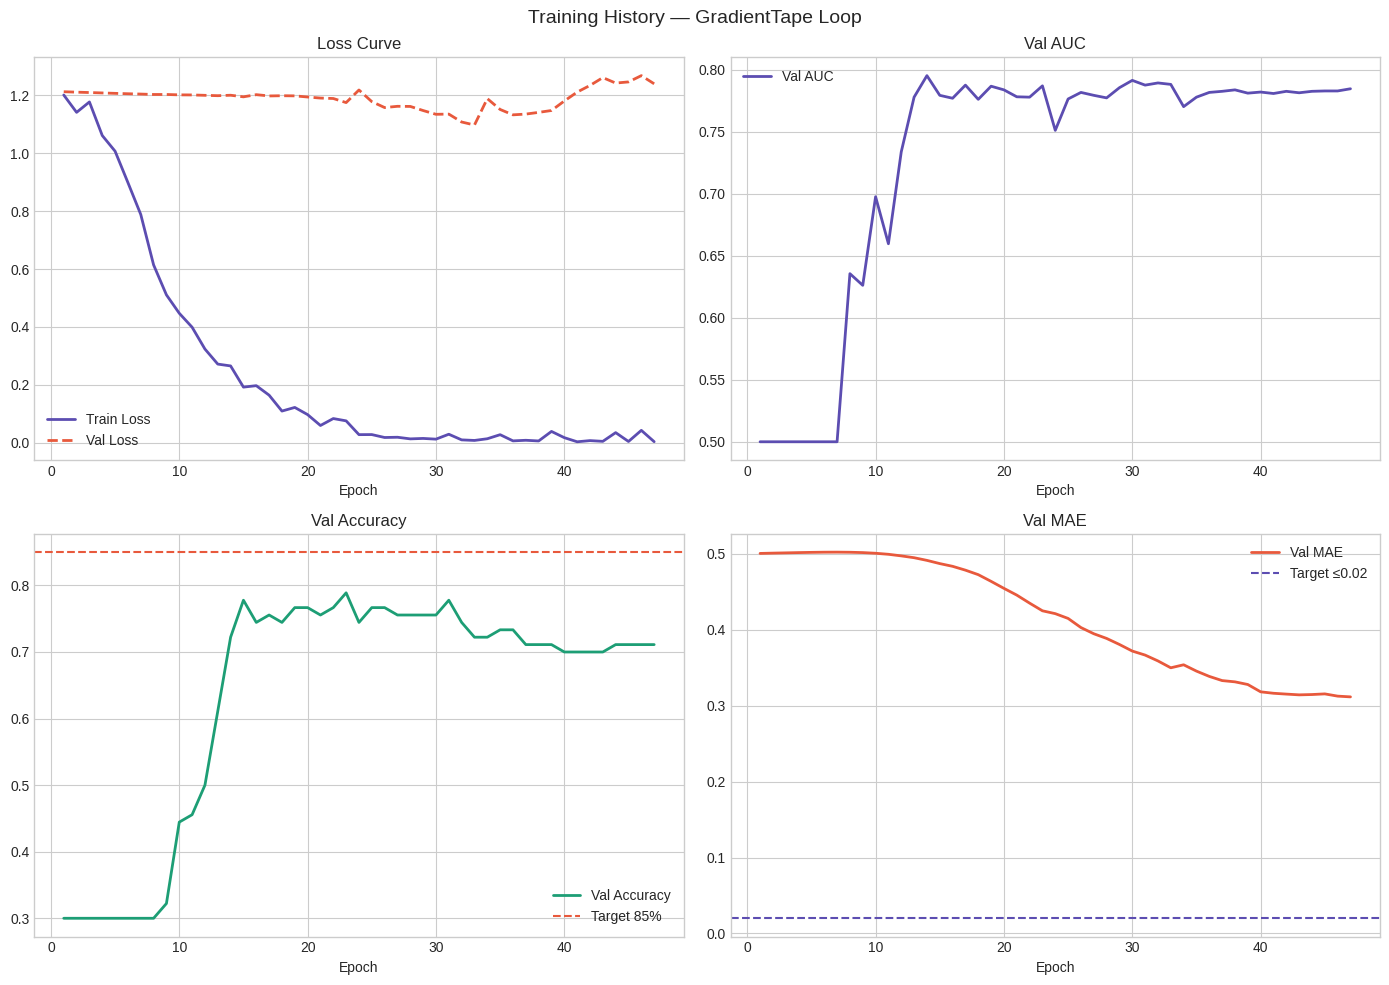

Best val_auc      : 0.7951
Best val_accuracy : 0.7889
Best val_mae      : 0.3115
Best val_f1       : 0.8613


In [ ]:
# Training History Plot (dari custom loop history_gt)
epochs_ran = len(history_gt["loss"])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep_range, history_gt["loss"],         color=PLOT_COLOR, linewidth=2, label="Train Loss")
axes[0,0].plot(ep_range, history_gt["val_loss"],     color="#E8593C",  linewidth=2, linestyle="--", label="Val Loss")
axes[0,0].set_title("Loss Curve"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(ep_range, history_gt["val_auc"],      color=PLOT_COLOR, linewidth=2, label="Val AUC")
axes[0,1].set_title("Val AUC"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[1,0].plot(ep_range, history_gt["val_accuracy"], color="#1D9E75",  linewidth=2, label="Val Accuracy")
axes[1,0].axhline(0.85, color="#E8593C", linestyle="--", label="Target 85%")
axes[1,0].set_title("Val Accuracy"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

axes[1,1].plot(ep_range, history_gt["val_mae"],      color="#E8593C",  linewidth=2, label="Val MAE")
axes[1,1].axhline(0.02, color=PLOT_COLOR, linestyle="--", label="Target ≤0.02")
axes[1,1].set_title("Val MAE"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend()

plt.suptitle("Training History — GradientTape Loop", fontsize=14)
plt.tight_layout()
plt.savefig("/content/09_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best val_auc      : {max(history_gt['val_auc']):.4f}")
print(f"Best val_accuracy : {max(history_gt['val_accuracy']):.4f}")
print(f"Best val_mae      : {min(history_gt['val_mae']):.4f}")
print(f"Best val_f1       : {max(history_gt['val_f1']):.4f}")


In [ ]:
# Validation Report — cari threshold optimal dulu
from sklearn.metrics import f1_score as _f1

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
val_probs   = model.predict(X_val_tfidf, verbose=0).flatten()

best_thresh = max(thresholds,
    key=lambda t: _f1(Y_label_val, (val_probs >= t).astype(int),
                      average="binary", zero_division=0))

print(f"Optimal threshold (val F1): {best_thresh}")
CONFIG["prob_threshold"] = best_thresh

y_val_pred = (val_probs >= best_thresh).astype(int)
print("VALIDATION REPORT")
print(classification_report(Y_label_val, y_val_pred, zero_division=0))


Optimal threshold (val F1): 0.45
VALIDATION REPORT
              precision    recall  f1-score   support

           0       0.72      0.48      0.58        27
           1       0.81      0.92      0.86        63

    accuracy                           0.79        90
   macro avg       0.76      0.70      0.72        90
weighted avg       0.78      0.79      0.77        90



## 10. Evaluation

In [ ]:
# Test set evaluation
from sklearn.metrics import mean_absolute_error, accuracy_score

y_test_pred_prob = model.predict(X_test_tfidf, verbose=0)
y_test_pred      = (y_test_pred_prob >= CONFIG["prob_threshold"]).astype(int).flatten()

print("TEST SET REPORT")
print(classification_report(Y_label_test, y_test_pred, zero_division=0))

test_f1  = f1_score(Y_label_test, y_test_pred, average="binary", zero_division=0)
test_auc_m = tf.keras.metrics.AUC()
test_auc_m.update_state(Y_label_test, y_test_pred_prob)

test_acc = accuracy_score(Y_label_test, y_test_pred)
test_mae = mean_absolute_error(Y_label_test, y_test_pred_prob.flatten())

print(f"\n{'Metric':<18} {'Value':>8}   {'Status'}")
print(f"{'Test Accuracy':<18} {test_acc:>8.4f}   {'>= 85%' if test_acc >= 0.85 else  '< 85%'}")
print(f"{'Test MAE':<18} {test_mae:>8.4f}   {'<= 0.02' if test_mae <= 0.02 else '> 0.02'}")
print(f"{'Test F1':<18} {test_f1:>8.4f}")
print(f"{'Test AUC':<18} {test_auc_m.result().numpy():>8.4f}")


TEST SET REPORT
              precision    recall  f1-score   support

           0       0.65      0.48      0.55        27
           1       0.80      0.89      0.84        63

    accuracy                           0.77        90
   macro avg       0.73      0.69      0.70        90
weighted avg       0.76      0.77      0.76        90


Metric                Value   Status
Test Accuracy        0.7667   < 85%
Test MAE             0.3617   > 0.02
Test F1              0.8421
Test AUC             0.7989


In [ ]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, mean_absolute_error

print("Threshold tuning:")
print(f"{'Threshold':>12} {'Macro F1':>10} {'Acc':>8} {'F1-0':>8} {'F1-1':>8} {'Accuracy':>10}")

best_thresh, best_macro_f1 = 0.5, 0.0
for thresh in np.arange(0.10, 0.91, 0.05):
    thresh = round(thresh, 2)
    pred   = (y_test_pred_prob >= thresh).astype(int).flatten()
    macro  = f1_score(Y_label_test, pred, average="macro",    zero_division=0)
    f1_0   = f1_score(Y_label_test, pred, pos_label=0,        average="binary", zero_division=0)
    f1_1   = f1_score(Y_label_test, pred, pos_label=1,        average="binary", zero_division=0)
    acc    = accuracy_score(Y_label_test, pred)
    tag    = " ◀" if macro > best_macro_f1 else ""
    if macro > best_macro_f1:
        best_macro_f1, best_thresh = macro, thresh
    print(f"{thresh:>12.2f} {macro:>10.4f} {acc:>8.4f} {f1_0:>8.4f} {f1_1:>8.4f}{tag}")

CONFIG["prob_threshold"] = best_thresh
print(f"\n→ Optimal threshold: {best_thresh} (Macro F1={best_macro_f1:.4f})")

# Re-evaluate
y_test_pred  = (y_test_pred_prob >= best_thresh).astype(int).flatten()
test_acc     = accuracy_score(Y_label_test, y_test_pred)
test_mae     = mean_absolute_error(Y_label_test, y_test_pred_prob.flatten())
test_f1_best = f1_score(Y_label_test, y_test_pred, average="macro", zero_division=0)
test_auc_m2  = tf.keras.metrics.AUC()
test_auc_m2.update_state(Y_label_test, y_test_pred_prob)

print(f"\n{'Metric':<18} {'Value':>8}   Status")
print(f"{'Test Accuracy':<18} {test_acc:>8.4f}   {'>= 85%' if test_acc >= 0.85 else '< 85%'}")
print(f"{'Test MAE':<18} {test_mae:>8.4f}   {'<= 0.02' if test_mae <= 0.02 else '> 0.02'}")
print(f"{'Test Macro F1':<18} {test_f1_best:>8.4f}")
print(f"{'Test AUC':<18} {test_auc_m2.result().numpy():>8.4f}")

print(f"\nFINAL REPORT (threshold={best_thresh})")
print(classification_report(Y_label_test, y_test_pred, zero_division=0))

Threshold tuning:
   Threshold   Macro F1      Acc     F1-0     F1-1   Accuracy
        0.10     0.4040   0.6778   0.0000   0.8079 ◀
        0.15     0.4040   0.6778   0.0000   0.8079
        0.20     0.4400   0.6889   0.0667   0.8133 ◀
        0.25     0.5059   0.7111   0.1875   0.8243 ◀
        0.30     0.5286   0.7111   0.2353   0.8219 ◀
        0.35     0.5567   0.7222   0.2857   0.8276 ◀
        0.40     0.6368   0.7444   0.4390   0.8345 ◀
        0.45     0.6976   0.7667   0.5532   0.8421 ◀
        0.50     0.7353   0.7667   0.6441   0.8264 ◀
        0.55     0.6928   0.7111   0.6176   0.7679
        0.60     0.6558   0.6667   0.5946   0.7170
        0.65     0.6154   0.6222   0.5641   0.6667
        0.70     0.5950   0.6000   0.5500   0.6400
        0.75     0.5888   0.5889   0.5843   0.5934
        0.80     0.5439   0.5444   0.5591   0.5287
        0.85     0.5430   0.5444   0.5684   0.5176
        0.90     0.4440   0.4556   0.5243   0.3636

→ Optimal threshold: 0.5 (Macro F1=0

## 11. Save Artifacts

In [ ]:
# Save model .keras
model.save(PATHS["model_keras"])
print(f"Model saved    : {PATHS['model_keras']}")

# tfidf sudah disave di Section 6
print(f"TF-IDF saved   : {PATHS['tfidf_pkl']}")

# Save skill labels
with open(PATHS["label_json"], "w") as f:
    json.dump(SKILL_LABELS, f, indent=2)
print(f"Labels saved   : {PATHS['label_json']}")

# Verify load
loaded_model = keras.models.load_model(
    PATHS["model_keras"],
    custom_objects={"WeightedBCELoss": WeightedBCELoss, "SkillAttentionLayer": SkillAttentionLayer}
)
test_out = loaded_model.predict(X_test_tfidf[:1], verbose=0)
print(f"Model load verified — output: {test_out[0][0]:.4f}")

Model saved    : /content/skill_gap_model.keras
TF-IDF saved   : /content/tfidf_vectorizer.pkl
Labels saved   : /content/skill_labels.json
Model load verified — output: 0.2755


## 12. Inference Pipeline

In [ ]:
# Load artifacts
with open(PATHS["tfidf_pkl"], "rb") as f:
    tfidf_inf = pickle.load(f)
with open(PATHS["label_json"], "r") as f:
    skill_labels_inf = json.load(f)

inf_model = keras.models.load_model(
    PATHS["model_keras"],
    custom_objects={"WeightedBCELoss": WeightedBCELoss, "SkillAttentionLayer": SkillAttentionLayer}
)
print("Artifacts loaded for inference.")

Artifacts loaded for inference.


In [ ]:
def extract_cv_skills(cv_text: str, skill_labels: list) -> list:
    """Ekstrak skill dari CV via keyword matching vs taxonomy."""
    text = cv_text.lower()
    return [skill for skill in skill_labels if skill in text]

def predict_match(cv_text: str, jd_text: str, model, tfidf, threshold: float = 0.5) -> dict:
    """
    Inference pipeline: CV + JD → match probability.
    Steps:
      1. Clean & combine CV + JD text
      2. TF-IDF transform
      3. Model predict → match probability
    """
    combined  = clean_text(cv_text) + " " + clean_text(jd_text)
    X_vec     = tfidf.transform([combined]).toarray().astype("float32")
    prob      = float(model.predict(X_vec, verbose=0)[0][0])
    is_match  = prob >= threshold
    return {
        "match_probability" : round(prob, 4),
        "is_match"          : bool(is_match),
        "threshold"         : threshold,
    }

def compute_skill_gap(cv_text: str, jd_text: str, skill_labels: list) -> dict:
    """
    Hitung skill gap antara CV dan JD via keyword matching.
    Output JSON: cv_skills, required_skills, matched_skills, gap_skills, match_score
    """
    cv_skills       = set(extract_cv_skills(cv_text, skill_labels))
    jd_skills       = set(extract_cv_skills(jd_text, skill_labels))
    matched_skills  = cv_skills & jd_skills
    gap_skills      = jd_skills - cv_skills
    match_score     = round(len(matched_skills) / len(jd_skills) * 100, 1) if jd_skills else 0.0

    return {
        "cv_skills"      : sorted(cv_skills),
        "required_skills": sorted(jd_skills),
        "matched_skills" : sorted(matched_skills),
        "gap_skills"     : sorted(gap_skills),
        "match_score"    : f"{match_score}%",
    }

print("Inference functions defined.")

Inference functions defined.


In [ ]:
# End-to-end test
sample_cv = """
Python developer with 3 years experience in machine learning and sql.
Proficient in aws, docker, and git. Strong communication skills.
"""

sample_jd = """
We are looking for a Python developer with experience in sql and aws.
Knowledge of machine learning is a plus. Good communication required.
"""

# Match prediction
match_result = predict_match(sample_cv, sample_jd, inf_model, tfidf_inf)
print("MATCH PREDICTION")
for k, v in match_result.items():
    print(f"  {k:<22} : {v}")

# Skill gap
gap_result = compute_skill_gap(sample_cv, sample_jd, skill_labels_inf)
print("\n SKILL GAP ANALYSIS")
for k, v in gap_result.items():
    print(f"  {k:<22} : {v}")

MATCH PREDICTION
  match_probability      : 0.1623
  is_match               : False
  threshold              : 0.5

 SKILL GAP ANALYSIS
  cv_skills              : ['aws', 'communication', 'docker', 'git', 'python', 'sql']
  required_skills        : ['aws', 'communication', 'python', 'sql', 'ui']
  matched_skills         : ['aws', 'communication', 'python', 'sql']
  gap_skills             : ['ui']
  match_score            : 80.0%
